# Ejercicio 5: Estudio y Aplicación del Algoritmo Bayes Ingenuo

**Objetivo:** Estudiar el algoritmo de Bayes ingenuo (también conocido como Algoritmo Bayes simple o Bayes naive) y desarrollar un ejemplo bien documentado. 

Para este ejercicio, abordaremos un problema de aprendizaje supervisado la clasificación de correos electrónicos (filtro Spam).

## 1. Fundamentos Teóricos del Bayes Ingenuo

El algoritmo de Bayes ingenuo es un método de clasificación basado en el Teorema de Bayes, con la suposición "ingenua" de que todas las características (features) son condicionalmente independientes entre sí, dada la clase. 

El Teorema de Bayes se expresa matemáticamente como:

$$P(Y|X) = \frac{P(X|Y)P(Y)}{P(X)}$$

Donde:
* **$P(Y|X)$**: Probabilidad posterior de la clase $Y$ dada la característica $X$.
* **$P(X|Y)$**: Probabilidad condicional de observar $X$ si la clase es $Y$.
* **$P(Y)$**: Probabilidad a priori de la clase $Y$.
* **$P(X)$**: Probabilidad marginal de la característica $X$.

En el contexto de un filtro Spam, los desarrolladores antes usaban ingeniería de software tradicional para buscar patrones y palabras como “gratis”, “regalo” o “tarjeta de crédito”. Con Machine Learning, el algoritmo aprende estas probabilidades directamente del conjunto de entrenamiento (dataset).

In [14]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Creación del Dataset de Entrenamiento

El aprendizaje supervisado requiere entradas (características) y sus rótulos correspondientes. Usaremos un conjunto simulado y equilibrado de 48 correos: 24 Spam y 24 correos válidos. Los ejemplos son sintéticos y sirven para ilustrar el algoritmo; no sustituyen un corpus real para evaluar un filtro de producción.

In [15]:
# Dataset sintético de entrenamiento: 24 correos Spam y 24 correos válidos
correos_spam = [
    "Obtén una tarjeta de crédito gratis hoy mismo",
    "Reclama tu regalo sorpresa y crédito gratis",
    "Gana un regalo totalmente gratis ingresando aquí",
    "Aprobación de tarjeta de crédito sin costo",
    "Has ganado un premio en efectivo, reclama antes de medianoche",
    "Oferta exclusiva: duplica tus ingresos desde casa",
    "Tu paquete está retenido, paga ahora para recibirlo",
    "Felicidades, eres ganador de un teléfono nuevo",
    "Invierte hoy y recibe ganancias garantizadas",
    "Préstamo aprobado sin requisitos, solicita aquí",
    "Activa tu cuenta y evita el bloqueo haciendo clic",
    "Regalo VIP reservado para ti, confirma tus datos",
    "Descuento del 90 por ciento solo por hoy",
    "Reclama tus puntos antes de que caduquen, entra al enlace",
    "Gana dinero fácil con este método secreto",
    "Has sido seleccionado para recibir un bono gratuito",
    "Compra seguidores y aumenta tus ventas rápidamente",
    "Tu tarjeta fue preaprobada, responde con tus datos",
    "Oferta urgente de criptomonedas con retorno seguro",
    "Descarga este archivo para cobrar tu recompensa",
    "Última oportunidad para reclamar tu premio",
    "Consigue medicamentos sin receta con envío inmediato",
    "Entra aquí para recibir una tarjeta regalo gratis",
    "Haz clic para reclamar un bono exclusivo por tiempo limitado"
]

correos_normales = [
    "Hola, te envío el reporte de la reunión",
    "El proyecto está listo para producción",
    "¿Almorzamos a las 12 con el equipo?",
    "Revisión de los algoritmos de ML terminada",
    "Buenos días, ¿podemos reunirnos el jueves a las diez?",
    "Adjunto las notas de la clase de hoy",
    "El informe mensual está disponible en la carpeta compartida",
    "Te llamo después de terminar la presentación",
    "La reunión del equipo se cambia para el viernes",
    "Gracias por ayudarme con el proyecto",
    "Confirmé la reserva para la cena de esta noche",
    "¿Puedes revisar los resultados del experimento?",
    "El archivo solicitado está en el correo anterior",
    "Nos vemos en la oficina a primera hora",
    "El proveedor entregará los materiales mañana",
    "Recibí tu mensaje y responderé durante la tarde",
    "La factura del servicio vence el próximo mes",
    "Compartí el calendario actualizado con el grupo",
    "Necesito confirmar el horario de la consulta",
    "El curso comienza el lunes en el aula habitual",
    "¿Puedes enviarme la versión final del documento?",
    "El pedido llegó completo, muchas gracias",
    "Quedó pendiente revisar el presupuesto del viaje",
    "Te espero en la entrada de la biblioteca"
]

correos_entrenamiento = correos_spam + correos_normales
# Rótulos: 1 indica Spam y 0 indica correo normal (Ham)
rotulos_entrenamiento = np.array(
    [1] * len(correos_spam) + [0] * len(correos_normales)
)

print(f"Correos de entrenamiento: {len(correos_entrenamiento)}")
print(f"Spam: {len(correos_spam)} | Normales: {len(correos_normales)}")

Correos de entrenamiento: 48
Spam: 24 | Normales: 24


## 3. Extracción de Características y Entrenamiento

Como el algoritmo procesa números y no texto directo, utilizamos la técnica de "Bag of Words" (Bolsa de Palabras) para convertir los correos en vectores numéricos de frecuencias. Luego, instanciamos y entrenamos nuestro modelo Bayes ingenuo.

### ¿Qué aprende Naive Bayes?

Para cada clase (Spam o Normal), el modelo estima primero su probabilidad previa $P(Y)$ y, para cada palabra, la probabilidad de encontrarla en esa clase. Al clasificar un mensaje, combina esas probabilidades y elige la clase con mayor probabilidad posterior. En este caso usamos **Multinomial Naive Bayes**, apropiado para conteos de palabras. La suposición "ingenua" es que las palabras son independientes entre sí una vez conocida la clase; en el lenguaje real no siempre lo son, pero la aproximación suele ser útil.

En la versión multinomial, el conteo de cada palabra contribuye al puntaje de una clase: una palabra repetida aporta más evidencia. Scikit-learn calcula estos puntajes en escala logarítmica para evitar que muchas probabilidades pequeñas se multipliquen hasta redondearse a cero. Además, `alpha=1.0` aplica **suavizado de Laplace**: suma una unidad a los conteos para que una palabra que no apareció en una clase no haga que la probabilidad completa sea cero.

### ¿Qué hace la bolsa de palabras?

`CountVectorizer` construye un vocabulario a partir de los textos de entrenamiento y representa cada correo con un vector: cada posición corresponde a una palabra y su valor es cuántas veces aparece. Por ejemplo, para el vocabulario `["gratis", "reunión"]`, el texto `"gratis gratis reunión"` se representa como `[2, 1]`. Este método cuenta palabras, pero no conserva el orden ni el contexto.

In [16]:
# fit_transform aprende el vocabulario SOLO con entrenamiento y crea una fila
# por correo, con el número de apariciones de cada palabra.
vectorizador = CountVectorizer()
X_entrenamiento = vectorizador.fit_transform(correos_entrenamiento)

# MultinomialNB usa los conteos de palabras y las etiquetas para estimar
# la probabilidad previa de cada clase y la probabilidad de cada palabra
# dentro de cada clase. alpha=1.0 aplica suavizado de Laplace.
modelo_bayes = MultinomialNB(alpha=1.0)

# Durante fit, el modelo aprende a partir de los vectores y sus rótulos:
# 1 = Spam, 0 = Normal. No se le pasan directamente los textos originales.
modelo_bayes.fit(X_entrenamiento, rotulos_entrenamiento)

print("¡Modelo entrenado exitosamente!")
print("Cantidad de palabras en el vocabulario:", len(vectorizador.get_feature_names_out()))
print("Palabras en el vocabulario:", vectorizador.get_feature_names_out())

¡Modelo entrenado exitosamente!
Cantidad de palabras en el vocabulario: 216
Palabras en el vocabulario: ['12' '90' 'activa' 'actualizado' 'adjunto' 'ahora' 'al' 'algoritmos'
 'almorzamos' 'anterior' 'antes' 'aprobación' 'aprobado' 'aquí' 'archivo'
 'aula' 'aumenta' 'ayudarme' 'biblioteca' 'bloqueo' 'bono' 'buenos'
 'caduquen' 'calendario' 'cambia' 'carpeta' 'casa' 'cena' 'ciento' 'clase'
 'clic' 'cobrar' 'comienza' 'compartida' 'compartí' 'completo' 'compra'
 'con' 'confirma' 'confirmar' 'confirmé' 'consigue' 'consulta' 'correo'
 'costo' 'criptomonedas' 'crédito' 'cuenta' 'curso' 'datos' 'de' 'del'
 'descarga' 'descuento' 'desde' 'después' 'diez' 'dinero' 'disponible'
 'documento' 'duplica' 'durante' 'días' 'efectivo' 'el' 'en' 'enlace'
 'entra' 'entrada' 'entregará' 'enviarme' 'envío' 'equipo' 'eres' 'espero'
 'esta' 'este' 'está' 'evita' 'exclusiva' 'exclusivo' 'experimento'
 'factura' 'felicidades' 'final' 'fue' 'fácil' 'gana' 'ganado' 'ganador'
 'ganancias' 'garantizadas' 'gracias'

## 4. Predicción y Evaluación con Matriz de Confusión

Para evaluar qué tan bien hace la predicción nuestro modelo, utilizamos nuevas instancias (correos no vistos durante el entrenamiento) y analizamos los resultados mediante una Matriz de Confusión. `transform` convierte los mensajes usando el vocabulario ya aprendido, sin volver a ajustarlo con los datos de prueba; así evitamos filtrar información de prueba al entrenamiento. `predict` compara los puntajes de las clases y devuelve la clase más probable. La precisión es la proporción de predicciones correctas. Como aquí solo hay cuatro mensajes de prueba, el resultado ilustra el procedimiento, pero no mide de forma confiable el rendimiento general.

Resultados de la Predicción:
[Spam] -> Tienes un regalo gratis esperando
[Normal] -> Por favor revisa el documento adjunto
[Spam] -> Solicita tu tarjeta de crédito ahora
[Normal] -> Confirmación de cita médica

Exactitud del modelo: 100.0%


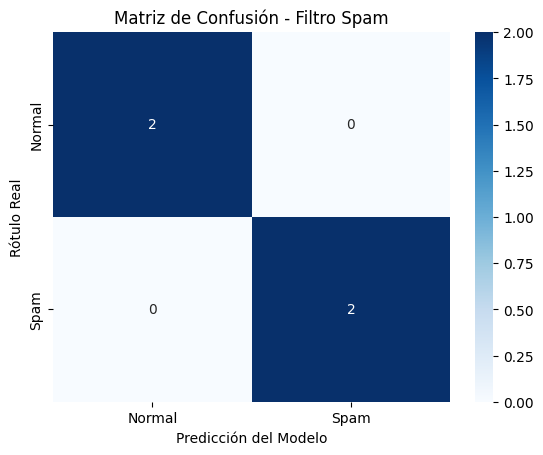

In [17]:
# Nuevas instancias para probar el modelo
correos_prueba = [
    "Tienes un regalo gratis esperando", # Debería ser Spam (1)
    "Por favor revisa el documento adjunto", # Debería ser Normal (0)
    "Solicita tu tarjeta de crédito ahora", # Debería ser Spam (1)
    "Confirmación de cita médica" # Debería ser Normal (0)
]

# Rótulos reales de las nuevas instancias
rotulos_reales = np.array([1, 0, 1, 0])

# Convertir correos nuevos con el vocabulario aprendido en entrenamiento.
# Se usa transform (no fit_transform) para no aprender de los datos de prueba.
X_prueba = vectorizador.transform(correos_prueba)

# predict estima la clase más probable (1 = Spam, 0 = Normal) para cada correo.
predicciones = modelo_bayes.predict(X_prueba)

print("Resultados de la Predicción:")
for correo, pred in zip(correos_prueba, predicciones):
    clase = "Spam" if pred == 1 else "Normal"
    print(f"[{clase}] -> {correo}")

# La matriz compara etiquetas reales (filas) con predicciones (columnas).
# El orden de las clases es [0 = Normal, 1 = Spam].
matriz_conf = confusion_matrix(rotulos_reales, predicciones)
# Exactitud = número de predicciones correctas / total de correos evaluados.
exactitud = accuracy_score(rotulos_reales, predicciones)

print(f"\nExactitud del modelo: {exactitud * 100}%")

# Visualización de la Matriz de Confusión
sns.heatmap(matriz_conf, annot=True, cmap="Blues", fmt="d", 
            xticklabels=["Normal", "Spam"], 
            yticklabels=["Normal", "Spam"])
plt.ylabel('Rótulo Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión - Filtro Spam')
plt.show()